In [2]:
# %% [markdown]
# # Imports

# %%
import numpy as np 
import h5py
import warnings

from egb_jax_eccentric import (
    EccentricBinaryParams,
    aet_from_xyz,
    eccentric_complex_strain,
    eccentric_links_jax,
    eccentric_xyz_jax,
    lisa_orbit,
    precompute_jax_link_geometry,
    default_lisaorbits, 
    state_from_lisaorbits
)
from egb_jax_eccentric.constants import PARSEC_M#, KILOPARSEC_M
from astropy.coordinates import SkyCoord, BarycentricTrueEcliptic
import astropy.units as u
import json
from scipy.signal import welch
# import matplotlib.pyplot as plt
import dynesty


# %%
import os
work_dir='/home/svu/e1498138/localgit/eGB-multi'
scratch_dir='/scratch/e1498138/eGB-multi'
os.chdir(work_dir)

inj_path = scratch_dir + '/sangria_hmcnc_true.h5'

# %% [markdown]
# # Read injected file

# %%
XYZ = ("X", "Y", "Z")
AET = ("A", "E", "T")

# %%
with h5py.File(inj_path, "r") as f:
    t = f["t"][:]
    noise_xyz = {"t": t, **{ch: f["noise"][ch][:] for ch in XYZ}}
    signal_xyz = {ch: f["eccentric_signal"][ch][:] for ch in XYZ}
    injected_xyz = {"t": t, **{ch: f["injected"][ch][:] for ch in XYZ}}

    dt = f.attrs["segment_dt_s"]
    sangria_metadata = json.loads(f.attrs["sangria_metadata_json"])
    source_params = json.loads(f.attrs["egb_source_params_json"])

print("samples:", t.size, "dt:", dt)
print("source_params:", json.dumps(source_params, indent=2))


# %%
state = state_from_lisaorbits(default_lisaorbits("equal"), t)
geometry = precompute_jax_link_geometry(state)

egb_pytdi_gen = 1
measurement_order = 3
delay_order = 3

# %% [markdown]
# # Rotate to AET & PSD Estimate

# %%
noise_aet = aet_from_xyz(noise_xyz)
signal_aet = aet_from_xyz(signal_xyz)
injected_aet = aet_from_xyz(injected_xyz)

print("noise AET max abs:", {ch: float(np.max(np.abs(noise_aet[ch]))) for ch in AET})
print("signal AET max abs:", {ch: float(np.max(np.abs(signal_aet[ch]))) for ch in AET})


# %%

fs = 1.0 / dt
nperseg = 8192 #like in the paper but do note its for dt=10s
# get psd on same grid
# nperseg = noise_xyz["X"].size 

psd_xyz, psd_aet = {}, {}
for ch in XYZ:
    freq, psd_xyz[ch] = welch(noise_xyz[ch], fs=fs, nperseg=nperseg, detrend="constant")
for ch in AET:
    _, psd_aet[ch] = welch(noise_aet[ch], fs=fs, nperseg=nperseg, detrend="constant")


# %% [markdown]
# # FFT of injected data

# %%
def fdom(x, dt):
    n = x.size
    xf = np.fft.rfft(x) * dt
    freq = np.fft.rfftfreq(n, d=dt)
    return freq, xf

ll_chan = ("A", "E") #exclude T cuz we hate it C:


# %%
data_freq, data_fd = {}, {}
for ch in ll_chan:
    data_freq_i, data_fd_i = fdom(injected_aet[ch], dt)
    data_freq[ch] = data_freq_i
    data_fd[ch] = data_fd_i


# %% [markdown]
# # Interpolate PSD on the same grid

# %%
def psd_on_grid(freq_grid, welch_freq, welch_psd):
    safe = welch_freq > 0
    log_psd = np.interp(np.log(freq_grid[freq_grid > 0]),
                         np.log(welch_freq[safe]), np.log(welch_psd[safe]))
    out = np.full_like(freq_grid, np.inf)
    out[freq_grid > 0] = np.exp(log_psd)
    return out

psd_grid = {}
for ch in ll_chan:
    psd_grid[ch] = psd_on_grid(data_freq[ch], freq, psd_aet[ch])

# %% [markdown]
# # Waveform template func

# %%
def htemp(params):
    # params to vary
    ecc_i, m1_sol_i, m2_sol_i = params
    source_temp = EccentricBinaryParams(
        mean_motion=np.pi * source_params["f0_hz"],
        eccentricity=ecc_i,
        m1_solar=m1_sol_i,
        m2_solar=m2_sol_i,
        distance_m=source_params["distance_m"],
        beta=source_params["beta"],
        lambda_=source_params["lambda_"],
        psi=source_params["psi"],
        inclination=source_params["inclination"],
        phi0=source_params["phi0"],
        fdot=source_params["fdot"],
    )

    raw_temp_xyz = eccentric_xyz_jax(
        state,
        source_temp,
        geometry=geometry,
        batch_size=1, #NOTE: think abt different sampler that is able to handle batched pool evaluations
        physics_mode="1pn_periastron", #NOTE: 1pn
        generation=egb_pytdi_gen,
        measurement_order=measurement_order,
        delay_order=delay_order,
    )
    xyz = {ch: np.real(np.asarray(raw_temp_xyz[ch], dtype=np.complex128)) for ch in XYZ}
    return aet_from_xyz(xyz)

# %% [markdown]
# # Log likelihood

# %%
# take freq min of the welch psd 
# its abt 10^-5 meanwhile injected data goes to 10^-7..

freq_min = freq[freq > 0].min()
freq_mask = data_freq["A"] >= freq_min

df = data_freq["A"][1] - data_freq["A"][0]

# %% [markdown]
# expand $-\frac12\langle d-h|d-h\rangle = -\frac12 \langle d|d\rangle + \langle d|h \rangle - \frac12 \langle h|h \rangle$

# %%
def log_likelihood(params):
    template_aet = htemp(params)
    logl = 0.0
    for ch in ("A", "E"):
        _, h_fd = fdom(template_aet[ch], dt)
        d = data_fd[ch][freq_mask]
        h = h_fd[freq_mask]
        sn = psd_grid[ch][freq_mask]
        dh = 4.0 * np.sum(np.real(d * np.conj(h)) / sn) * df
        hh = 4.0 * np.sum(np.real(h * np.conj(h)) / sn) * df
        logl += dh - 0.5 * hh
    return float(logl)

# %% [markdown]
# # Priors

# %%
def prior_transform(u):
    ecc_u, m1_u, m2_u = u
    eccentricity = ecc_u * 0.9          # uniform prior: e in [0, 0.9)
    m1_solar = 0.1 + m1_u * (1.5 - 0.1)  # uniform prior: m1 in [0.1, 1.5] Msun
    m2_solar = 0.1 + m2_u * (1.5 - 0.1)  # same range for m2
    return eccentricity, m1_solar, m2_solar



samples: 518400 dt: 5.0
source_params: {
  "f0_hz": 0.00622027623506547,
  "eccentricity": 0,
  "m1_solar": 0.55,
  "m2_solar": 0.27,
  "distance_m": 2.3142581861185254e+20,
  "beta": -0.08210049881437637,
  "lambda_": 2.102052384246663,
  "psi": 0.0,
  "inclination": 0.6632251157578453,
  "phi0": 0.0,
  "fdot": 0.0
}


/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch/e1498138/anaconda3/envs/egb-multi/lib/python3.11/site-packages/lisaconstants/compat/astropy.py:252: UserWarning: The following constants differ between lisaconstants and the version of astropy you have installed: VACUUM_PERMEABILITY. The recommended version of astropy is 7.2.0. Use a different one at your own risks. 
You may also open an issue at https://gitlab.esa.int/lisa-sgs/commons/lisa-constants to warn that lisaconstants is not compatible with astropy v8.0.1
  warnings.warn(


noise AET max abs: {'A': 4.3858327704197363e-20, 'E': 4.459085751762551e-20, 'T': 5.263813956477628e-20}
signal AET max abs: {'A': 2.626181161966582e-23, 'E': 1.2889563994147257e-23, 'T': 6.743698074007531e-26}


In [3]:
import dynesty
checkpoint_path = scratch_dir + "/hmcnc_true_ckpt.save"

sampler = dynesty.NestedSampler.restore(checkpoint_path)
results = sampler.results


# NOTE: dlogz ~ 0.1 !! 

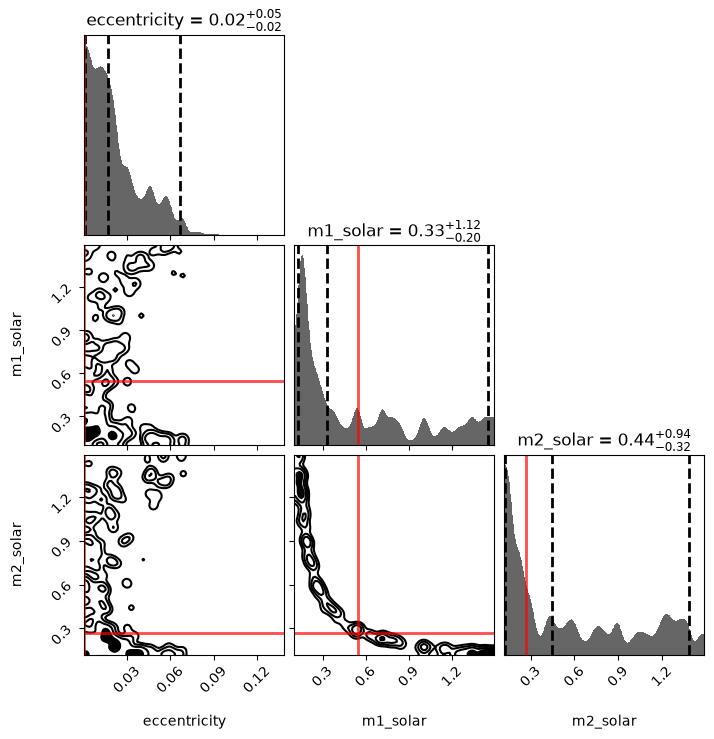

In [4]:
from dynesty import plotting as dyplot

fig, axes = dyplot.cornerplot(
    results,
    labels=["eccentricity", "m1_solar", "m2_solar"],
    truths=[source_params["eccentricity"], source_params["m1_solar"], source_params["m2_solar"]],
    show_titles=True,
)
